In [1]:
import pandas as pd

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")

In [2]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print(delivered_orders.shape)

(96478, 8)


In [9]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    delivered_orders[col] = pd.to_datetime(delivered_orders[col])

In [4]:
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

In [5]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [6]:
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"]
    >
    delivered_orders["order_estimated_delivery_date"]
).astype(int)

In [7]:
late_rate = (
    delivered_orders["is_late"].mean()
) * 100

print(
    f"Late Delivery Rate: {late_rate:.2f}%"
)

Late Delivery Rate: 8.11%


# State-wise SLA Breach Analysis

Objective:
Identify states with the highest percentage of late deliveries to understand regional logistics challenges.

In [10]:
sla_state = delivered_orders.merge(
    customers,
    on="customer_id",
    how="left"
)

sla_state.shape

(96478, 14)

In [11]:
state_late = (
    sla_state
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
)

state_late["late_rate"] = (
    state_late["late_orders"]
    / state_late["total_orders"]
) * 100

state_late = state_late.sort_values(
    by="late_rate",
    ascending=False
)

state_late.head(10)

,total_orders,late_orders,late_rate
customer_state,,,
AL,397,95,23.929471
MA,717,141,19.665272
PI,476,76,15.966387
CE,1279,196,15.324472
SE,335,51,15.223881
BA,3256,457,14.035627
RJ,12350,1664,13.473684
TO,274,35,12.773723
PA,946,117,12.367865


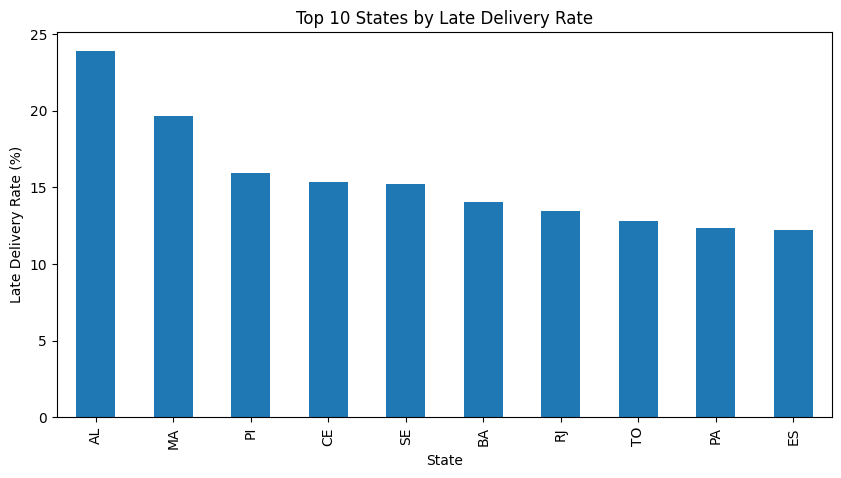

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

state_late.head(10)["late_rate"].plot(
    kind="bar"
)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("State")
plt.ylabel("Late Delivery Rate (%)")
plt.show()

# Seller Performance Analysis

Objective:
Identify sellers contributing most to SLA breaches.

In [13]:
seller_orders = delivered_orders.merge(
    items,
    on="order_id",
    how="left"
)

seller_orders.shape

(110197, 16)

In [14]:
seller_late = (
    seller_orders
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
)

seller_late["late_rate"] = (
    seller_late["late_orders"]
    / seller_late["total_orders"]
) * 100

In [15]:
seller_late = seller_late[
    seller_late["total_orders"] >= 50
]

In [16]:
seller_late = seller_late.sort_values(
    by="late_rate",
    ascending=False
)

seller_late.head(10)

,total_orders,late_orders,late_rate
seller_id,,,
54965bbe3e4f07ae045b90b0b8541f52,81,26,32.098765
2a1348e9addc1af5aaa619b1a3679d6b,51,15,29.411765
6039e27294dc75811c0d8a39069f52c0,74,19,25.675676
a49928bcdf77c55c6d6e05e09a9b4ca5,104,26,25.000000
602044f2c16190c2c6e45eb35c2e21cb,55,13,23.636364
06a2c3af7b3aee5d69171b0e14f0ee87,402,95,23.631841
beadbee30901a7f61d031b6b686095ad,68,16,23.529412
cac4c8e7b1ca6252d8f20b2fc1a2e4af,82,19,23.170732
ea566164622c6b439516ab18062c42cd,52,12,23.076923


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = seller_orders[
    [
        "price",
        "freight_value",
        "delivery_days",
        "is_late"
    ]
].copy()

In [21]:
corr_matrix = heatmap_df.corr()

corr_matrix

,price,freight_value,delivery_days,is_late
price,1.000000,0.412722,0.062313,0.020920
freight_value,0.412722,1.000000,0.214658,0.040427
delivery_days,0.062313,0.214658,1.000000,0.585350
is_late,0.020920,0.040427,0.585350,1.000000


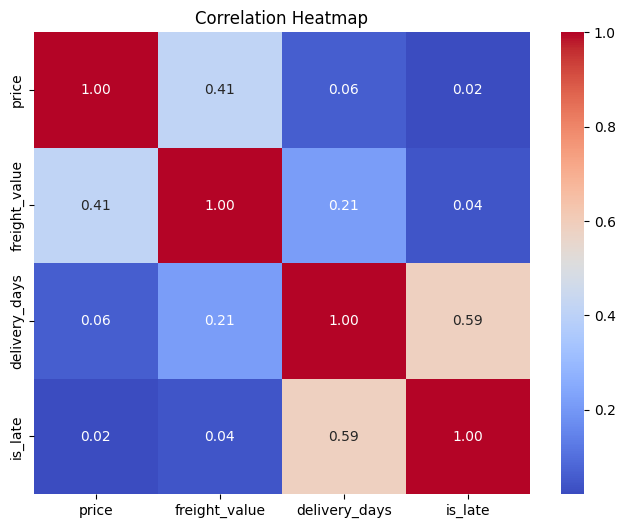

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

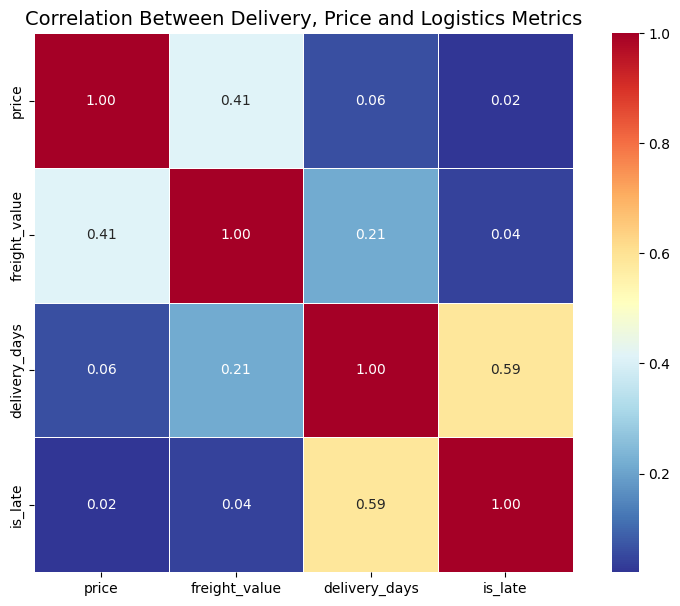

In [23]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title(
    "Correlation Between Delivery, Price and Logistics Metrics",
    fontsize=14
)

plt.show()

# Seller Performance Analysis

Objective:
Identify sellers contributing most to SLA breaches.

In [24]:
seller_orders = delivered_orders.merge(
    items[["order_id", "seller_id"]],
    on="order_id",
    how="left"
)

seller_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,seller_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0,3504c0cb71d7fa48d967e0e4c94d59d9
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,0,289cdb325fb7e7f891c38608bf9e0962
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0,4869f7a5dfa277a7dca6462dcf3b52b2
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0,66922902710d126a0e7d26b0e3805106
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0,2c9e548be18521d1c43cde1c582c6de8


In [25]:
seller_late = (
    seller_orders
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
)

seller_late["late_rate"] = (
    seller_late["late_orders"]
    /
    seller_late["total_orders"]
) * 100

In [26]:
seller_late = seller_late[
    seller_late["total_orders"] >= 50
]

In [27]:
seller_late = seller_late.sort_values(
    by="late_rate",
    ascending=False
)

seller_late.head(10)

,total_orders,late_orders,late_rate
seller_id,,,
54965bbe3e4f07ae045b90b0b8541f52,81,26,32.098765
2a1348e9addc1af5aaa619b1a3679d6b,51,15,29.411765
6039e27294dc75811c0d8a39069f52c0,74,19,25.675676
a49928bcdf77c55c6d6e05e09a9b4ca5,104,26,25.000000
602044f2c16190c2c6e45eb35c2e21cb,55,13,23.636364
06a2c3af7b3aee5d69171b0e14f0ee87,402,95,23.631841
beadbee30901a7f61d031b6b686095ad,68,16,23.529412
cac4c8e7b1ca6252d8f20b2fc1a2e4af,82,19,23.170732
ea566164622c6b439516ab18062c42cd,52,12,23.076923


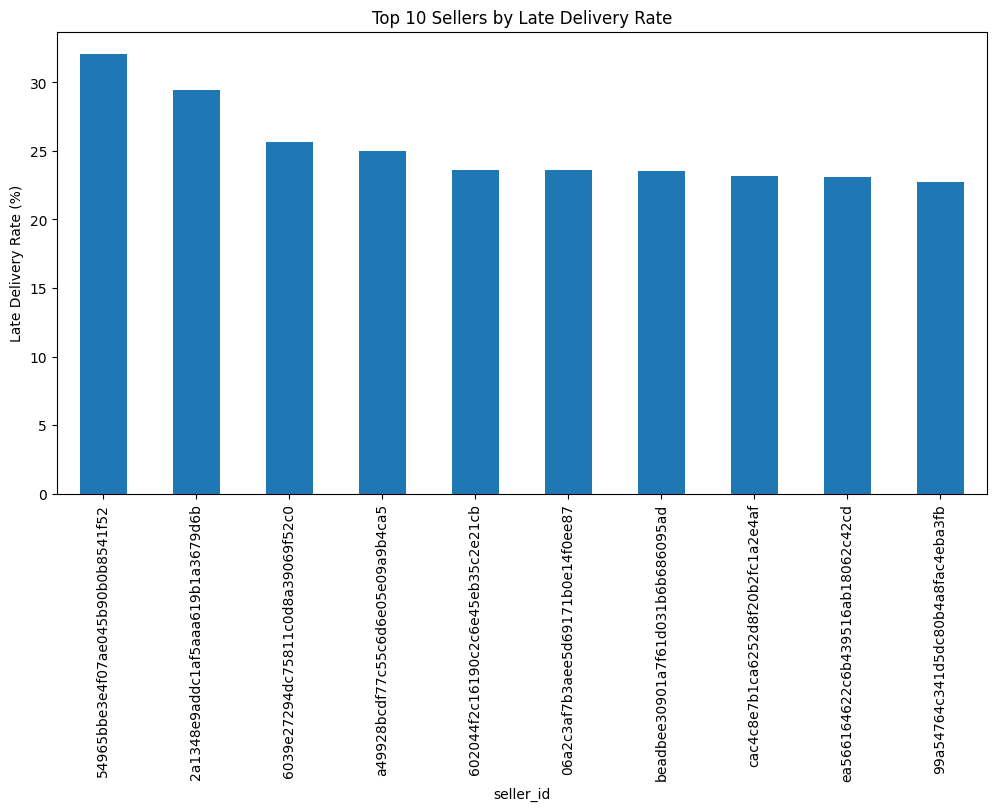

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

seller_late.head(10)["late_rate"].plot(
    kind="bar"
)

plt.title(
    "Top 10 Sellers by Late Delivery Rate"
)

plt.ylabel(
    "Late Delivery Rate (%)"
)

plt.show()